# Quasi Monte Carlo

In [18]:
import numpy as np
from scipy import stats
from scipy.stats.sampling import FastGeneratorInversion

In [19]:
# Define the gamma distribution with shape
shape = 2
scale = 2
expected_mean = shape * scale
gamma_frozen = stats.gamma(shape, scale=scale)
gamma_dist = FastGeneratorInversion(gamma_frozen)

# Generate random samples using both methods
n = 100000
r_mq = gamma_dist.rvs(size=n)
r_qmc = gamma_dist.qrvs(size=n)/scale # Scale the quasi-random samples to match the distribution

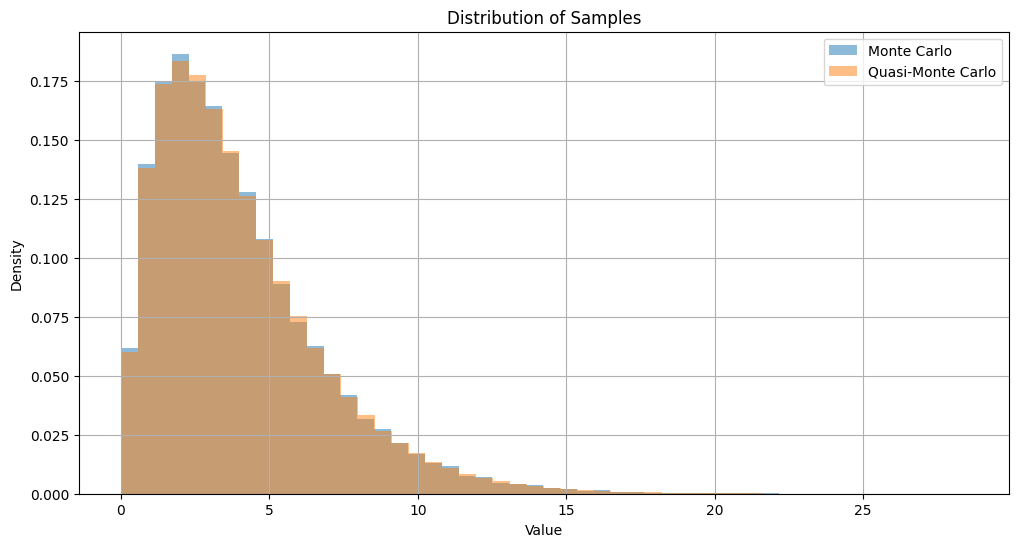

In [15]:
# plot distribution of samples
plt.figure(figsize=(12, 6))
plt.hist(r_mq, bins=50, density=True, alpha=0.5, label='Monte Carlo')
plt.hist(r_qmc, bins=50, density=True, alpha=0.5, label='Quasi-Monte Carlo')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Distribution of Samples')
plt.legend()
plt.grid()
plt.show()

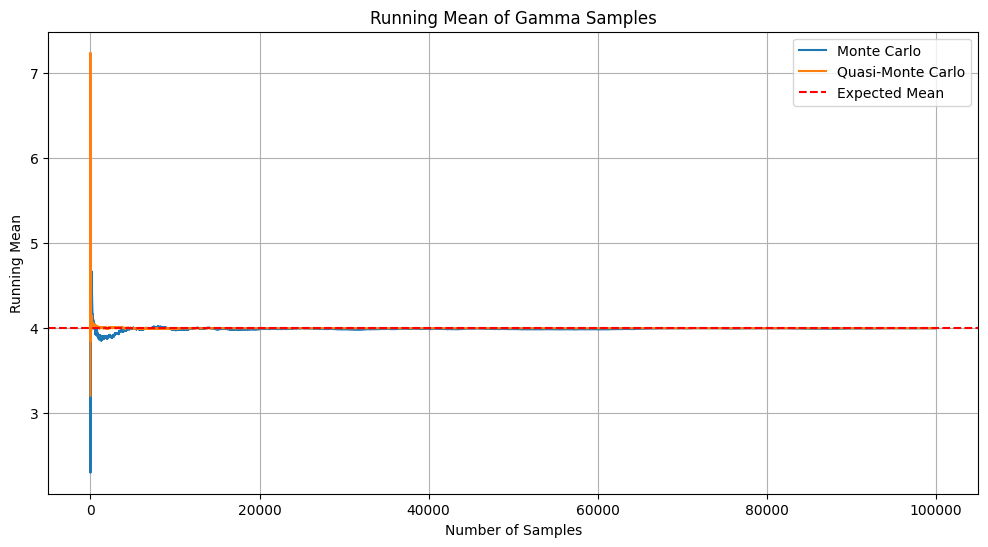

In [20]:
# plot the running mean of the samples
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(np.cumsum(r_mq) / np.arange(1, n + 1), label='Monte Carlo')
plt.plot(np.cumsum(r_qmc) / np.arange(1, n + 1), label='Quasi-Monte Carlo')
plt.axhline(expected_mean, color='red', linestyle='--', label='Expected Mean')
plt.xlabel('Number of Samples')
plt.ylabel('Running Mean')
plt.title('Running Mean of Gamma Samples')
plt.legend()
plt.grid()
plt.show()

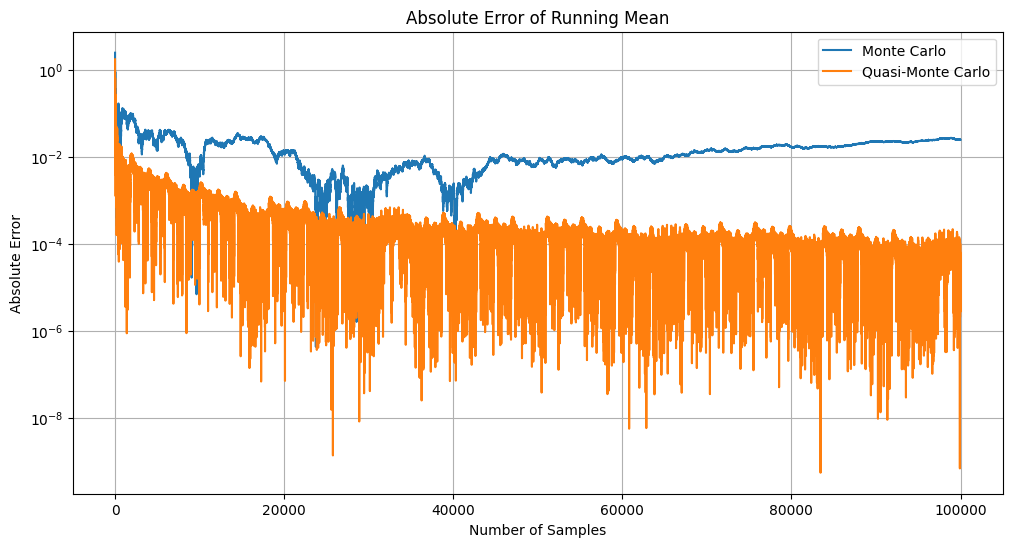

In [17]:
# plot the log plot of the absolute error
plt.figure(figsize=(12, 6))
plt.semilogy(np.arange(1, n + 1), np.abs(np.cumsum(r_mq) / np.arange(1, n + 1) - expected_mean), label='Monte Carlo')
plt.semilogy(np.arange(1, n + 1), np.abs(np.cumsum(r_qmc) / np.arange(1, n + 1) - expected_mean), label='Quasi-Monte Carlo')
plt.xlabel('Number of Samples')
plt.ylabel('Absolute Error')
plt.title('Absolute Error of Running Mean')
plt.legend()
plt.grid()
plt.show()

# Sobol Sequence QMC

Now let's implement QMC using Sobol sequences and compare with the existing methods.

In [21]:
from scipy.stats import qmc

# Generate Sobol sequences
sobol_sampler = qmc.Sobol(d=1, scramble=True)
sobol_points = sobol_sampler.random(n)
sobol_uniform = sobol_points.flatten()

# Transform to gamma distribution using inverse CDF
r_sobol = gamma_frozen.ppf(sobol_uniform)

/var/folders/mf/hsszjj6n6m366lncpcrpp1th0000gp/T/ipykernel_91037/2201991935.py:5: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sobol_points = sobol_sampler.random(n)


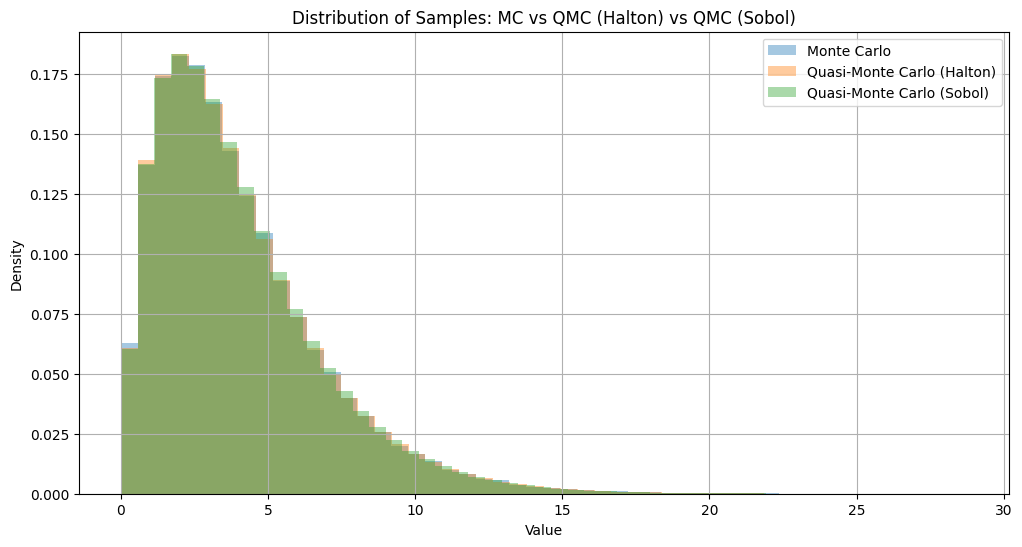

In [22]:
# Plot distribution comparison including Sobol
plt.figure(figsize=(12, 6))
plt.hist(r_mq, bins=50, density=True, alpha=0.4, label='Monte Carlo')
plt.hist(r_qmc, bins=50, density=True, alpha=0.4, label='Quasi-Monte Carlo (Halton)')
plt.hist(r_sobol, bins=50, density=True, alpha=0.4, label='Quasi-Monte Carlo (Sobol)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Distribution of Samples: MC vs QMC (Halton) vs QMC (Sobol)')
plt.legend()
plt.grid()
plt.show()

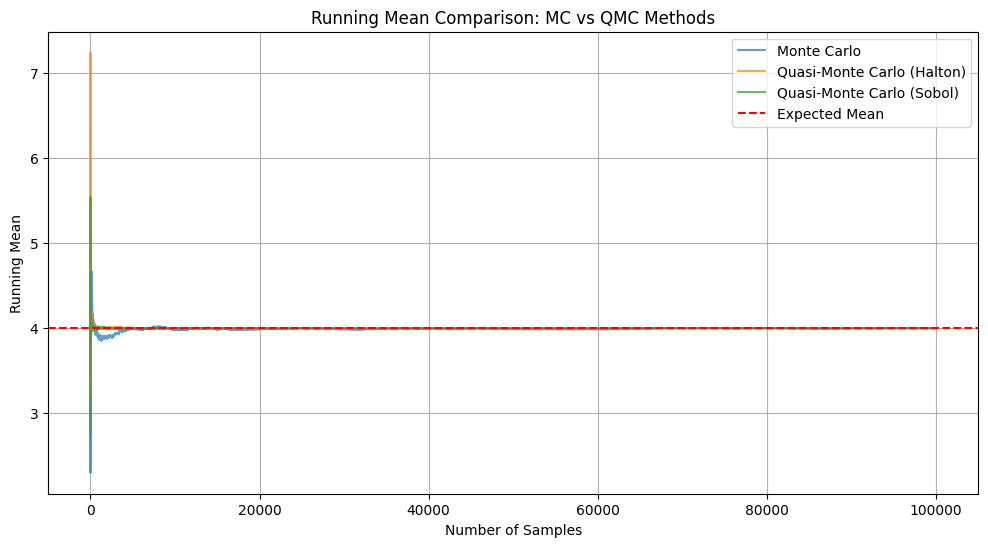

In [23]:
# Plot running mean comparison
plt.figure(figsize=(12, 6))
plt.plot(np.cumsum(r_mq) / np.arange(1, n + 1), label='Monte Carlo', alpha=0.7)
plt.plot(np.cumsum(r_qmc) / np.arange(1, n + 1), label='Quasi-Monte Carlo (Halton)', alpha=0.7)
plt.plot(np.cumsum(r_sobol) / np.arange(1, n + 1), label='Quasi-Monte Carlo (Sobol)', alpha=0.7)
plt.axhline(expected_mean, color='red', linestyle='--', label='Expected Mean')
plt.xlabel('Number of Samples')
plt.ylabel('Running Mean')
plt.title('Running Mean Comparison: MC vs QMC Methods')
plt.legend()
plt.grid()
plt.show()

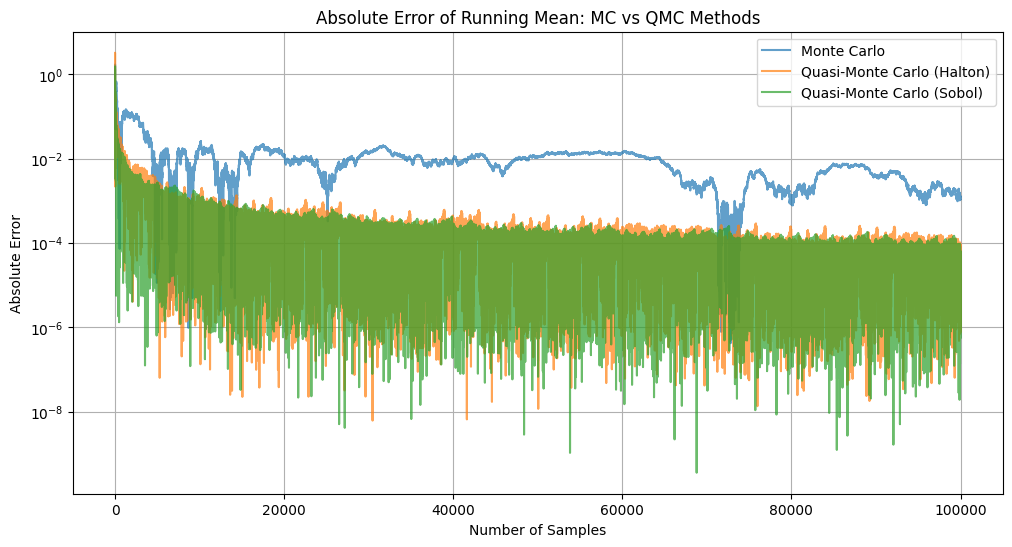

In [24]:
# Plot absolute error comparison on log scale
plt.figure(figsize=(12, 6))
plt.semilogy(np.arange(1, n + 1), np.abs(np.cumsum(r_mq) / np.arange(1, n + 1) - expected_mean), label='Monte Carlo', alpha=0.7)
plt.semilogy(np.arange(1, n + 1), np.abs(np.cumsum(r_qmc) / np.arange(1, n + 1) - expected_mean), label='Quasi-Monte Carlo (Halton)', alpha=0.7)
plt.semilogy(np.arange(1, n + 1), np.abs(np.cumsum(r_sobol) / np.arange(1, n + 1) - expected_mean), label='Quasi-Monte Carlo (Sobol)', alpha=0.7)
plt.xlabel('Number of Samples')
plt.ylabel('Absolute Error')
plt.title('Absolute Error of Running Mean: MC vs QMC Methods')
plt.legend()
plt.grid()
plt.show()

In [25]:
# Compute final statistics
mc_mean = np.mean(r_mq)
qmc_halton_mean = np.mean(r_qmc)
qmc_sobol_mean = np.mean(r_sobol)

mc_var = np.var(r_mq, ddof=1)
qmc_halton_var = np.var(r_qmc, ddof=1)
qmc_sobol_var = np.var(r_sobol, ddof=1)

print(f"Expected Mean: {expected_mean:.4f}")
print(f"Monte Carlo Mean: {mc_mean:.4f}, Variance: {mc_var:.4f}")
print(f"QMC (Halton) Mean: {qmc_halton_mean:.4f}, Variance: {qmc_halton_var:.4f}")
print(f"QMC (Sobol) Mean: {qmc_sobol_mean:.4f}, Variance: {qmc_sobol_var:.4f}")

# Compute RMS error for the last 10% of samples
last_10pct = int(0.1 * n)
mc_error = np.sqrt(np.mean((np.cumsum(r_mq) / np.arange(1, n + 1) - expected_mean)[last_10pct:]**2))
qmc_halton_error = np.sqrt(np.mean((np.cumsum(r_qmc) / np.arange(1, n + 1) - expected_mean)[last_10pct:]**2))
qmc_sobol_error = np.sqrt(np.mean((np.cumsum(r_sobol) / np.arange(1, n + 1) - expected_mean)[last_10pct:]**2))

print(f"\nRMS Error (last 10% of samples):")
print(f"Monte Carlo: {mc_error:.6f}")
print(f"QMC (Halton): {qmc_halton_error:.6f}")
print(f"QMC (Sobol): {qmc_sobol_error:.6f}")

Expected Mean: 4.0000
Monte Carlo Mean: 3.9989, Variance: 8.0484
QMC (Halton) Mean: 4.0000, Variance: 7.9986
QMC (Sobol) Mean: 4.0000, Variance: 7.9988

RMS Error (last 10% of samples):
Monte Carlo: 0.009229
QMC (Halton): 0.000191
QMC (Sobol): 0.000124


Quasi